## Setup + Load

In [7]:
import duckdb
import pandas as pd
from pathlib import Path
import numpy as np

POSTS_FILE = "../datasets/posts.parquet"
PROFILES_FILE = "../datasets/profiles.parquet"

A = pd.Timestamp("2025-01-01")
B = pd.Timestamp("2025-04-01")   # 3 months 
DELTA_DAYS = 30
DELTA = pd.Timedelta(days=DELTA_DAYS)
OUTPUT_DIR = "../datasets/derived"

con = duckdb.connect()

In [8]:
#ispezione schema

def list_columns(parquet_file: str) -> list[str]:
    q = f"SELECT * FROM parquet_scan('{parquet_file}') LIMIT 0"
    return con.execute(q).df().columns.tolist()

profiles_cols = list_columns(PROFILES_FILE)
posts_cols = list_columns(POSTS_FILE)

profiles_cols, posts_cols

(['did_id',
  'rkey',
  'created_at',
  'description',
  'labels',
  'avatar',
  'banner',
  'joined_via_starter_pack',
  'additional_fields'],
 ['did_id',
  'rkey',
  'created_at',
  'languages',
  'labels',
  'tags',
  'embed_type',
  'embed_record',
  'embed_external_uri',
  'embed_images',
  'embed_media',
  'embed_video',
  'reply'])

## Making of Last Acitivity file
### this file consider only accounts with at least one post in [A, B-EXCLUSIVE]

In [9]:
last_activity_file = str(Path(OUTPUT_DIR) / "last_activity_3m.parquet")

con.execute(f"""
COPY (
    SELECT
        did_id,
        MAX(TRY_CAST(created_at AS TIMESTAMP)) AS last_activity,
        COUNT(*) AS n_posts_in_window
    FROM parquet_scan('{POSTS_FILE}')
    WHERE TRY_CAST(created_at AS TIMESTAMP) >= ?
      AND TRY_CAST(created_at AS TIMESTAMP) < ?
      AND did_id IS NOT NULL
      AND TRY_CAST(created_at AS TIMESTAMP) IS NOT NULL
    GROUP BY did_id
) TO '{last_activity_file}' (FORMAT PARQUET)
""", [A, B])

print(f"\nSalvato: {last_activity_file}")



Salvato: ..\datasets\derived\last_activity_3m.parquet


In [10]:
model_file = str(Path(OUTPUT_DIR) / "model_proxy_td.parquet")

con.execute(f"""
COPY (
    WITH profiles_base AS (
        SELECT
            did_id,
            TRY_CAST(created_at AS TIMESTAMP) AS profile_created_at
        FROM parquet_scan('{PROFILES_FILE}')
        WHERE did_id IS NOT NULL
          AND TRY_CAST(created_at AS TIMESTAMP) IS NOT NULL
    ),
    last_activity AS (
        SELECT *
        FROM parquet_scan('{last_activity_file}')
    )
    SELECT
        p.did_id,
        p.profile_created_at,
        l.last_activity,
        l.n_posts_in_window
    FROM profiles_base p
    INNER JOIN last_activity l
        ON p.did_id = l.did_id
    WHERE p.profile_created_at <= ?
) TO '{model_file}' (FORMAT PARQUET)
""", [A])

print(f"Salvato: {model_file}")

Salvato: ..\datasets\derived\model_proxy_td.parquet


In [ ]:

df = con.execute(f"SELECT * FROM '{model_file}'").df()

df["profile_created_at"] = pd.to_datetime(df["profile_created_at"], errors="coerce", utc=True)
df["last_activity"] = pd.to_datetime(df["last_activity"], errors="coerce", utc=True)

A_utc = pd.Timestamp(A, tz="UTC")
B_utc = pd.Timestamp(B, tz="UTC")

# proxy: inattivo da almeno DELTA giorni prima di B
df["proxy_td"] = df["last_activity"] <= (B_utc - DELTA)

# tutti partono da A
df["duration_days"] = (df["last_activity"] - A_utc).dt.total_seconds() / 86400.0

# pulizia robusta
df = df[df["duration_days"].notna()]
df = df[df["duration_days"] >= 0]

#takes only those with proxy_td = True
positives = df[df["proxy_td"]].copy()

print("\n=== DATASET SUMMARY ===")
print("N account nel modello:", len(df))
print("N positivi proxy:", len(positives))
print("Share positivi proxy:", len(positives) / len(df) if len(df) else np.nan)



=== DATASET SUMMARY ===
N account nel modello: 3303665
N positivi proxy: 1419166
Share positivi proxy: 0.4295732164126811


## Analisi Matematica Tempo di vita Medio 

In [14]:
print(df.columns.tolist())
print(positives["duration_days"].describe())
print((positives["duration_days"] < 0).sum())

['did_id', 'profile_created_at', 'last_activity', 'n_posts_in_window', 'proxy_td', 'duration_days']
count    1.419166e+06
mean     3.112458e+01
std      1.699193e+01
min      2.123843e-05
25%      1.812901e+01
50%      3.064136e+01
75%      4.572682e+01
max      5.999997e+01
Name: duration_days, dtype: float64
0


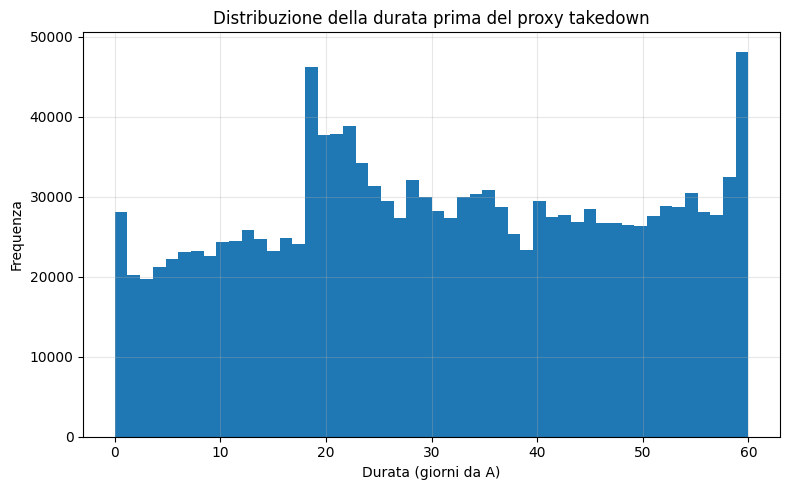

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    positives["duration_days"],
    bins=50
)

plt.xlabel("Durata (giorni da A)")
plt.ylabel("Frequenza")
plt.title("Distribuzione della durata prima del proxy takedown")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()  

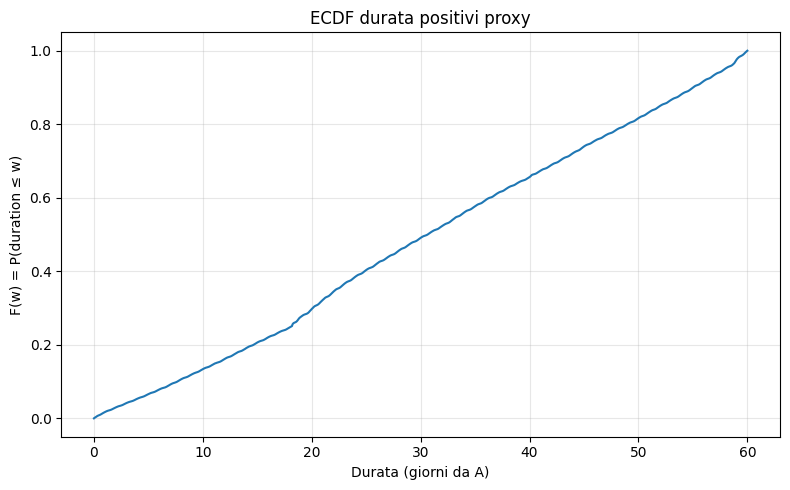

In [17]:
# ordina i valori
x = np.sort(positives["duration_days"].to_numpy())

# costruisci ECDF
y = np.arange(1, len(x) + 1) / len(x)

plt.figure(figsize=(8,5))
plt.step(x, y, where="post")

plt.xlabel("Durata (giorni da A)")
plt.ylabel("F(w) = P(duration ≤ w)")
plt.title("ECDF durata positivi proxy")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

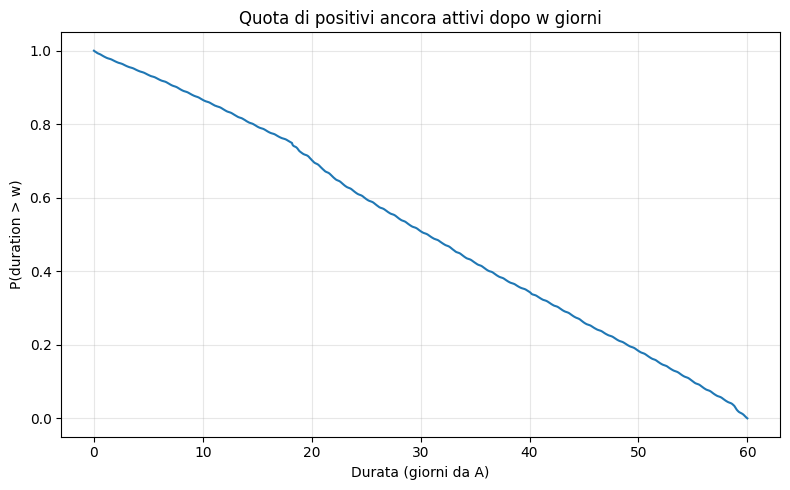

In [18]:
plt.figure(figsize=(8,5))
plt.step(x, 1 - y, where="post")

plt.xlabel("Durata (giorni da A)")
plt.ylabel("P(duration > w)")
plt.title("Quota di positivi ancora attivi dopo w giorni")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
candidate_windows = [1, 4, 7, 10, 14, 21, 30, 45, 60]

for w in candidate_windows:
    share = (positives["duration_days"] >= w).mean()
    print(f"{w} giorni → {share:.3f}")

1 giorni → 0.983
4 giorni → 0.946
7 giorni → 0.908
10 giorni → 0.866
14 giorni → 0.809
21 giorni → 0.678
30 giorni → 0.509
45 giorni → 0.260
60 giorni → 0.000
